# Extended Data Figure 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

# Define colour palette:
pal = sns.diverging_palette(250, 13, s=100, l=35, sep=2, center='light', as_cmap=True)

# Define the reversal potential of excitatory (Eexc) and inhibitory currents (Einh) 
# as difference to the leak reversal potential (Eleak):
Eexc = +50.0 # Eexc is 50 mV more positive than Eleak
Einh = -10.0 # Einh is 10 mV more neagtive than Eleak

k = 1 # conductance scaling relative to gleak (1 means no scaling)


# Calculate membrane potential with all reversal potentials as differences to Eleak
def calc_Vm(circuit, x, y, Eexc=Eexc, Einh=Einh):
    
    # ...for two excitatory inputs:
    if circuit == 'b':
        Vm = Eexc*(x+y)/(x+y+1)
        
    # ...and for one excitatory combined with the release from one inhibitory input:
    # (Note that the inhibitory conductance now decreases with increasing signal y.)    
    if circuit == 'c':
        Vm = (Eexc*x+Einh*(k-y))/(x+(k-y)+1)
        
    return Vm


# calc_response calculates the nonlinear response component at steady state
# as the difference between the baseline-subtracted voltage response to both
# coincident inputs (r12) and the sum of the baseline-subtracted responses to
# both inputs applied in isolation (r1 and r2, respectively):
def calc_nonlinearity(var, circuit, x=1, y=1, Eexc=Eexc, Einh=Einh):
    
    nonlinearity = np.zeros((11,11))
    
    # For varying input signal amplitudes:
    if var == 'xy':
        for i in range(11):
            x = i*0.1*k
            for j in range(11):
                y = 0.1*j*k
        
                # For two excitatory inputs:
                if circuit == 'b':
                    bl = calc_Vm(circuit='b',x=0,y=0) # calculate baseline (x=0,y=0)
                    r12 = calc_Vm(circuit='b',x=x,y=y) - bl
                    r1 = calc_Vm(circuit='b',x=x,y=0) - bl
                    r2 = calc_Vm(circuit='b',x=0,y=y) - bl

                    nonlinearity[j,i] = r12 - (r1+r2) # calculate the nonlinear response component
                    
                # For one excitatory and the release from an inhibitory input:
                if circuit == 'c':
                    bl = calc_Vm(circuit='c',x=0,y=0) # calculate baseline (x=0,y=0)
                    r12 = calc_Vm(circuit='c',x=x,y=y) - bl
                    r1 = calc_Vm(circuit='c',x=x,y=0) - bl
                    r2 = calc_Vm(circuit='c',x=0,y=y) - bl
                
                    nonlinearity[j,i] = r12 - (r1+r2) # calculate the nonlinear response component
    
    # For varying reveral potentials:
    if var == 'E':
        for idxe, e in enumerate(np.arange(0,+55,5)):
            Eexc = e*k
            for idxi, i in enumerate(np.arange(-50,5,5)):
                Einh = i
                
                bl = calc_Vm(circuit='c',Eexc=Eexc,Einh=Einh,x=0,y=0) # calculate baseline (x=0,y=0)
                r12 = calc_Vm(circuit='c',Eexc=Eexc,Einh=Einh,x=x,y=y) - bl
                r1 = calc_Vm(circuit='c',Eexc=Eexc,Einh=Einh,x=x,y=0) - bl
                r2 = calc_Vm(circuit='c',Eexc=Eexc,Einh=Einh,x=0,y=y) - bl
            
                nonlinearity[idxi,idxe] = r12 - (r1+r2) # calculate the nonlinear response component
            
    return nonlinearity

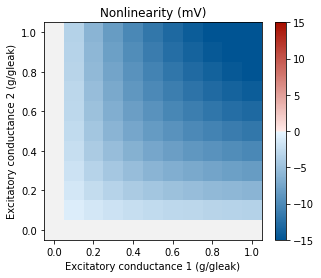

In [2]:
# Extended Data Figure 5b (combination of two excitatory inputs):
nonlinearity = calc_nonlinearity(var='xy', circuit='b')

plt.figure(figsize=(4.9,4))
plt.imshow(nonlinearity, origin='lower',vmin=-15, vmax=15, cmap=pal)
plt.xticks(np.arange(6)*2,np.arange(6)/5.0*k)
plt.yticks(np.arange(6)*2,np.arange(6)/5.0*k)
plt.xlabel('Excitatory conductance 1 (g/gleak)')
plt.ylabel('Excitatory conductance 2 (g/gleak)')
plt.title('Nonlinearity (mV)')
plt.colorbar();
#plt.savefig('effig5b.pdf', dpi=300);

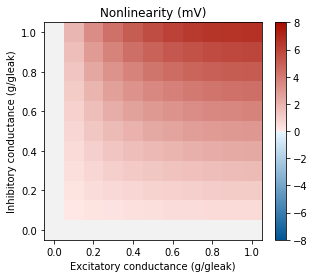

In [3]:
# Extended Data Figure 5c (combination of one excitatory input and release from one inhibitory input):

nonlinearity = calc_nonlinearity(var='xy', circuit='c')

plt.figure(figsize=(4.9,4))
plt.imshow(nonlinearity, origin='lower',vmin=-8, vmax=8, cmap=pal)
plt.xticks(np.arange(6)*2,np.arange(6)/5.0*k)
plt.yticks(np.arange(6)*2,np.arange(6)/5.0*k)
plt.xlabel('Excitatory conductance (g/gleak)')
plt.ylabel('Inhibitory conductance (g/gleak)')
plt.title('Nonlinearity (mV)')
plt.colorbar();
#plt.savefig('effig5c.pdf', dpi=300);

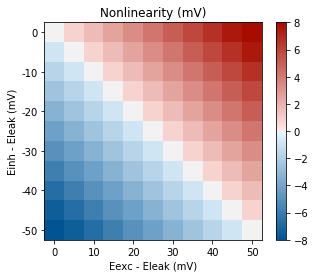

In [4]:
# Extended Data Figure 5d:
nonlinearity = calc_nonlinearity(var='E', circuit='c')

plt.figure(figsize=(4.9,4))
plt.imshow(nonlinearity, origin='lower',vmin=-8, vmax=8,cmap=pal)
plt.xticks(np.arange(6)*2,np.arange(0,+55,10))
plt.yticks(np.arange(6)*2,np.arange(-50,5,10))
plt.xlabel('Eexc - Eleak (mV)')
plt.ylabel('Einh - Eleak (mV)')
plt.title('Nonlinearity (mV)')
plt.colorbar();
#plt.savefig('edfig5d.pdf', dpi=300);

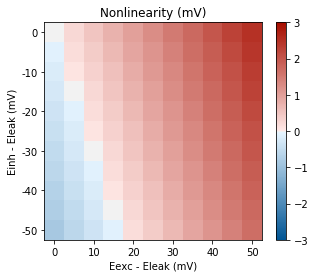

In [5]:
# Extended Data Figure 5e:
nonlinearity = calc_nonlinearity(var='E', circuit='c', x=0.5, y=0.5)

plt.figure(figsize=(4.9,4))
plt.imshow(nonlinearity,vmin=-3, vmax=3, origin='lower',cmap=pal)
plt.xticks(np.arange(6)*2,np.arange(0,+55,10))
plt.yticks(np.arange(6)*2,np.arange(-50,5,10))
plt.xlabel('Eexc - Eleak (mV)')
plt.ylabel('Einh - Eleak (mV)')
plt.title('Nonlinearity (mV)')
plt.colorbar();
#plt.savefig('edfig5e.pdf', dpi=300);